In [19]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path


In [20]:
image_path = Path('/home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025_edited/map.pgm')
output_path = Path('.').parent / '../output'  
output_path.mkdir(exist_ok=True)

print(f"Processing {image_path}...")

Processing /home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025_edited/map.pgm...


In [21]:
map_folder = image_path.parent

In [22]:
# log content
log_file = map_folder / 'map.yaml'
with open(log_file, 'r') as f:
    log_content = f.readlines()
log_content = [line.strip() for line in log_content if line.strip()]
log_content

['image: map.pgm',
 'mode: trinary',
 'resolution: 0.05',
 'origin: [-5.51, -7.61, 0]',
 'negate: 0',
 'occupied_thresh: 0.65',
 'free_thresh: 0.25']

In [23]:
# List the directory contents recursively
def list_files_recursively(directory):
    for path in directory.rglob('*'):
        if path.is_file():
            print(path)
list_files_recursively(map_folder)

/home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025_edited/map.pgm
/home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025_edited/map_start_line.png
/home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025_edited/map.data
/home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025_edited/map.yaml
/home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025_edited/map.posegraph
/home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025_edited/racing_lines/map_race_line_edit.xcf
/home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025_edited/racing_lines/map_race_line_drawn.xcf
/home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025_edited/raci

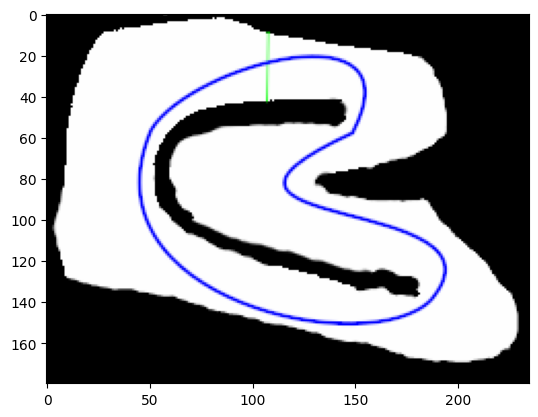

In [24]:
# Load racing_lines/map_race_line_drawn.png
racing_lines_path = map_folder / 'racing_lines' / 'map_race_line_drawn.png'
# racing_lines = cv2.imread(str(racing_lines_path), cv2.COLOR_RGB2BGR)
racing_lines = cv2.imread(str(racing_lines_path), cv2.COLOR_BGR2RGB)
# racing_lines = cv2.imread(str(racing_lines_path), cv2.COLOR_BGR2GRAY)
# Show the image
plt.imshow(racing_lines)

In [26]:
def mask_red_regions(image):
    # Convert the image from BGR to HSV color space
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    # Define the range for red color in HSV
    # Red has two ranges in HSV due to the hue wrapping around 0/360 degrees
    lower_red1 = np.array([0, 100, 100])    # Lower bound for red (0-10 hue)
    upper_red1 = np.array([10, 255, 255])   # Upper bound for red
    lower_red2 = np.array([170, 100, 100])  # Lower bound for red (170-180 hue)
    upper_red2 = np.array([180, 255, 255])  # Upper bound for red
    
    # Create masks for both red ranges
    mask1 = cv2.inRange(hsv_image, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv_image, lower_red2, upper_red2)
    
    # Combine the masks (bitwise OR)
    red_mask = cv2.bitwise_or(mask1, mask2)
    
    # Apply the mask to the original image
    red_only_image = cv2.bitwise_and(image, image, mask=red_mask)
    
    return red_only_image

In [ ]:
racing_line = mask_red_regions(racing_lines)


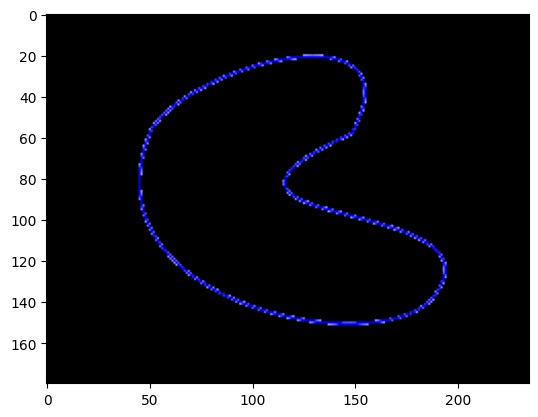

In [28]:
# Show the image
plt.imshow(racing_line)

In [29]:
def get_points_from_image(image):
    if len(image.shape) == 3:  # Check if image is color (3 channels)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        # Ensure the skeleton is binary (0 or 255)
    _, image = cv2.threshold(image, 1, 255, cv2.THRESH_BINARY)

    # Find contours
    contours, _ = cv2.findContours(image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    print(f"Found {len(contours)} contours")
    # Check if any contours were found
    if not contours:
        print("Error: No contours found. Ensure the skeleton contains non-zero pixels.")
        return np.array([], dtype=np.float64)

    # Select the first contour (assuming a single skeleton line)
    contour = contours[0]

    # Extract points from the contour
    # Contour points are in the format [[[x, y]], [[x, y]], ...]
    points = contour.reshape(-1, 2).astype(np.float64)

    print(f"Extracted {len(points)} points from contour")
    return points

In [34]:
racing_line_points = get_points_from_image(racing_line)
# racing_line_points.reshape(2, -1)
racing_line_points.shape

Found 1 contours
Extracted 460 points from contour


(460, 2)

In [35]:
def sample_waypoints(points: np.ndarray, num_points: int) -> np.ndarray:
    """
    Sample a specified number of waypoints evenly along a polyline defined by points.

    Args:
        points: An (N,2) array of (x,y) coordinates defining the path.
        num_points: Number of waypoints to sample.

    Returns:
        An (num_points,2) array of sampled (x,y) coordinates.
    """
    # Compute segment lengths
    diffs = np.diff(points, axis=0)
    seg_lengths = np.hypot(diffs[:,0], diffs[:,1])
    cumulative = np.concatenate(([0], np.cumsum(seg_lengths)))
    total_length = cumulative[-1]

    # Desired distances along the path
    distances = np.linspace(0, total_length, num_points)

    # Allocate output
    waypoints = np.zeros((num_points, 2), dtype=float)

    # Walk through segments to interpolate
    idx = 0
    for i, d in enumerate(distances):
        # Move idx to segment containing this distance
        while idx < len(cumulative)-2 and d > cumulative[idx+1]:
            idx += 1
        # Interpolate between points[idx] and points[idx+1]
        t = (d - cumulative[idx]) / (cumulative[idx+1] - cumulative[idx]) if cumulative[idx+1] > cumulative[idx] else 0
        waypoints[i] = (1 - t) * points[idx] + t * points[idx+1]
    return waypoints

In [36]:
sampled_points = sample_waypoints(racing_line_points, 100)
sampled_points.shape



(100, 2)

Text(0.5, 1.0, 'Sampled Points on Racing Line')

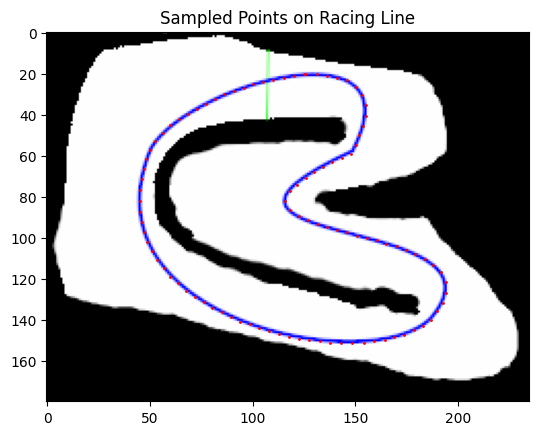

In [37]:
# show the sampled points
plt.imshow(racing_lines)
plt.scatter(sampled_points[:, 0], sampled_points[:, 1], c='red', s=1)
plt.title('Sampled Points on Racing Line')
